In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

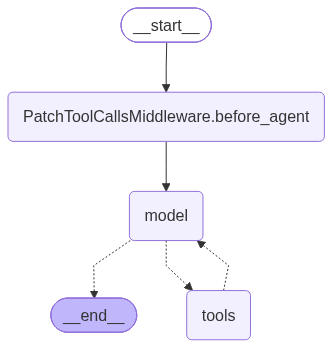

In [2]:
import os
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,

):
 """Run a web search"""
 return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )


research_subagent={
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a great researcher",
    "tools": [internet_search],
    "model": "groq:qwen/qwen3-32b",  # Optional override, defaults to main agent model

}
subagents=[research_subagent]

agent=create_deep_agent(
    model="openai:gpt-5.4",
    subagents=subagents
)
agent

In [3]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "Reserach about LLM Gateways and provide me a detailed summary.",       
          }],
          
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Reserach about LLM Gateways and provide me a detailed summary.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Here’s a detailed summary of **LLM Gateways**: what they are, why teams use them, the main capabilities they provide, the architecture patterns involved, the tradeoffs, and representative vendors/tools.\n\n---\n\n# What is an LLM Gateway?\n\nAn **LLM Gateway** is an infrastructure layer that sits between your applications and one or more large language model providers.\n\nInstead of your app calling OpenAI, Anthropic, Google, Azure OpenAI, local models, or other endpoints directly, it calls the **gateway**. The gateway then handles routing, policy enforcement, observability, security, reliability, and cost controls.\n\nYou can think of it as an API gateway or service mesh, but specialized for AI/LLM traffic.\n\n---\n\n# Why LLM Gateways

In [4]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent

class ResearchFindings(BaseModel):
    """Structured findings from a research task."""
    summary: str = Field(description="Summary of findings")
    confidence: float = Field(description="Confidence score from 0 to 1")
    sources: list[str] = Field(description="List of source URLs")

research_subagent = {
    "name": "researcher",
    "description": "Researches topics and returns structured findings",
    "system_prompt": "Research the given topic thoroughly. Return your findings.",
    "tools": [internet_search],
    "response_format": ResearchFindings,
}

agent = create_deep_agent(
    model="openai:gpt-5.4",
    subagents=[research_subagent],
)

result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Research recent advances in quantum computing"}]}
)

In [5]:
# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research recent advances in quantum computing
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Here’s a concise overview of recent advances in quantum computing, focusing on the last couple of years:\n\n## 1. Better hardware scale and quality\n- **IBM** has continued increasing qubit counts and improving modular architectures, with a roadmap focused not just on more qubits but on **error-corrected logical qubits**.\n- **Google** and others have emphasized reducing error rates and improving calibration, since raw qubit count alone is no longer seen as the main milestone.\n- **IonQ, Quantinuum, and trapped-ion groups** have shown strong progress in high-fidelity gates, which is important for reliable computation.\n- **Neutral-atom platforms** (such as QuEra, Pasqal, and academic labs) have rapidly improved and are now serious contenders, especially